# Entrenamiento y Exportación a ONNX

Simulacion > EDA > **ENTRENAMIENTO**

Modelado de ML. Entrenaremos dos modelos:
1. **Clasificador NLP (Categorización de Transacciones)**: Pasa texto libre a una de las 9 categorías.
2. **Perfilador Financiero (Estado de Salud)**: Clasifica la salud financiera del usuario a partir de sus variables numéricas.

Finalmente, exportaremos ambos modelos en formato **.onnx** para que el backend en Java pueda consumirlos directamente.

## 1. Preparación del Entorno
*Librerías necesarias para el entrenamiento y la conversión a ONNX.*

In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Librerías para exportar a ONNX (deben estar en el requirements.txt del contenedor)
from skl2onnx import to_onnx
from skl2onnx.common.data_types import StringTensorType, FloatTensorType

SEED = 42
np.random.seed(SEED)
print("Entorno y librerías preparadas correctamente.")


Entorno y librerías preparadas correctamente.


## 2. Modelo 1: Clasificador de Transacciones (NLP)
*Entrenamos un pipeline que convierte el texto de descripción en vectores numéricos usando TF-IDF y clasifica el gasto usando Regresión Logística.*

Vuelve la matriz de confusión

> investigar: tfidvectorizer, support

--- EVALUACIÓN MODELO NLP ---
              precision    recall  f1-score   support

     Ahorros       1.00      1.00      1.00       113
Alimentacion       1.00      1.00      1.00       116
      Deudas       1.00      1.00      1.00       110
   Educacion       1.00      1.00      1.00       110
        Ocio       1.00      1.00      1.00       112
       Salud       1.00      1.00      1.00       110
   Servicios       1.00      1.00      1.00       114
  Transporte       1.00      1.00      1.00       108
    Vivienda       1.00      1.00      1.00       107

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



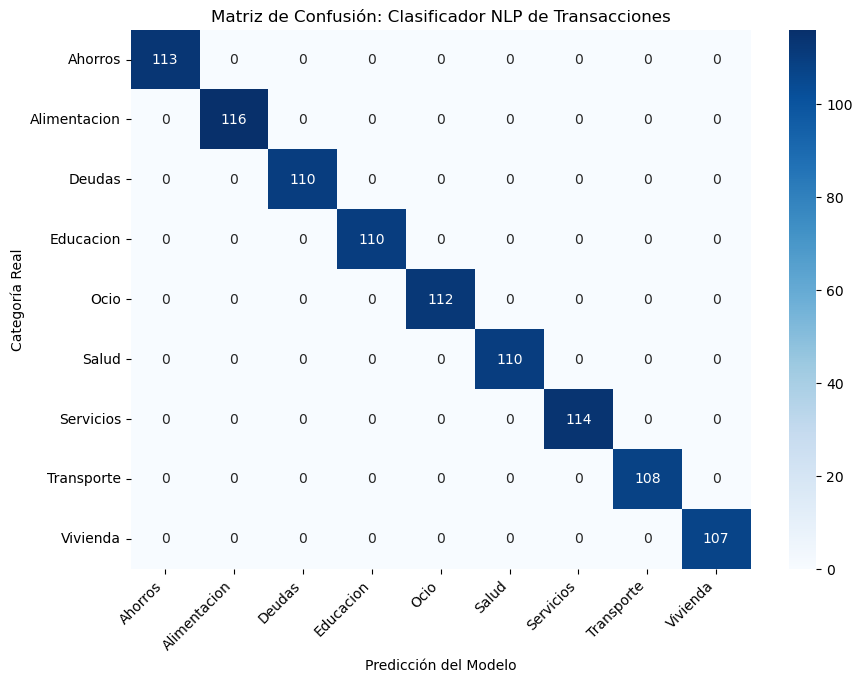

In [2]:
# Carga y separación de datos
df_tx = pd.read_csv("data/transacciones.csv")

X_text = df_tx["descripcion"]
y_text = df_tx["categoria"]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_text, y_text, test_size=0.2, random_state=SEED, stratify=y_text
)

# Creación del Pipeline de NLP
nlp_pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])

# Entrenamiento
nlp_pipeline.fit(X_train_t, y_train_t)

# Evaluación y matriz de confusión
preds_t = nlp_pipeline.predict(X_test_t)
print("--- EVALUACIÓN MODELO NLP ---")
print(classification_report(y_test_t, preds_t))

# ==============================================================================
# Graficamos la Matriz de Confusión para evaluar visualmente si el modelo confunde
# categorías. Se guarda la imágen en ./plots.
# ==============================================================================
cm_nlp = confusion_matrix(y_test_t, preds_t, labels=nlp_pipeline.classes_)
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_nlp, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=nlp_pipeline.classes_, 
    yticklabels=nlp_pipeline.classes_
)
plt.title("Matriz de Confusión: Clasificador NLP de Transacciones")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Categoría Real")
plt.xticks(rotation=45, ha="right")
os.makedirs("plots", exist_ok=True)
#plt.savefig("plots/matriz_confusion_nlp.png", bbox_inches="tight", dpi=150)
plt.show()


## 3. Modelo 2: Perfilador Financiero (Perfil de Riesgo)

Para facilitar la vida del equipo de Java, **convertiremos los textos a números en Python antes del modelo**. En lugar de pasar cadenas de texto al ONNX, convertiremos la variable de ahorro en floats: 
- `Ninguna` = 0.0
- `Baja` = 1.0
- `Media` = 2.0
- `Alta` = 3.0

De esta forma, el ONNX sólo recibirá un vector de 3 floats: `[ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro_val]`, simplificando la inferencia en el backend.

> investigar: ONNX

--- EVALUACIÓN MODELO PERFILADO ---
                precision    recall  f1-score   support

En observacion       0.87      0.86      0.87        95
     En riesgo       0.92      0.83      0.87        69
     Saludable       0.82      1.00      0.90        36

      accuracy                           0.88       200
     macro avg       0.87      0.90      0.88       200
  weighted avg       0.88      0.88      0.87       200



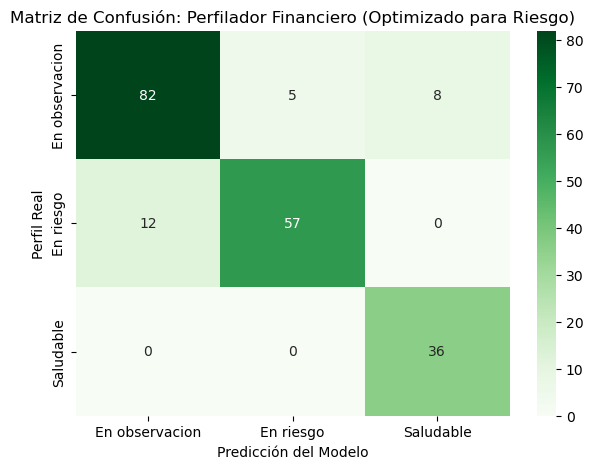

In [3]:
# Carga y preprocesamiento numérico
df_usr = pd.read_csv("data/usuarios.csv")

ahorro_map = {"Ninguna": 0.0, "Baja": 1.0, "Media": 2.0, "Alta": 3.0} # <<<

df_usr_encoded = df_usr.copy()
df_usr_encoded["frecuencia_ahorro_val"] = df_usr_encoded["frecuencia_ahorro"].map(ahorro_map)

# Inputs (3 floats) y Target
X_usr = df_usr_encoded[["ingreso_mensual", "nivel_endeudamiento", "frecuencia_ahorro_val"]].astype(np.float32)
y_usr = df_usr_encoded["perfil_financiero"]

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_usr, y_usr, test_size=0.2, random_state=SEED, stratify=y_usr
)

# ==============================================================================
# OPTIMIZACIÓN FINANCIERA PARA PRODUCCIÓN:
# Usamos class_weight="balanced" y max_depth=5 para priorizar el Recall de la clase "En riesgo".
# Esto evita que clientes de alto riesgo sean clasificados como seguros (Falsos Negativos),
# reduciendo el costo de morosidad y defaults en una aplicación fintech real.
# ==============================================================================
profiler_model = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=SEED) # Cambiado el max_depth de 4 a 5
profiler_model.fit(X_train_u, y_train_u)

# Evaluación y matriz de cnfusión
preds_u = profiler_model.predict(X_test_u)
print("--- EVALUACIÓN MODELO PERFILADO ---")
print(classification_report(y_test_u, preds_u))

# Matriz de confusión para el perfilador de salud financiera
cm_prof = confusion_matrix(y_test_u, preds_u, labels=profiler_model.classes_)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_prof, 
    annot=True, 
    fmt="d", 
    cmap="Greens", 
    xticklabels=profiler_model.classes_, 
    yticklabels=profiler_model.classes_
)
plt.title("Matriz de Confusión: Perfilador Financiero (Optimizado para Riesgo)")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Perfil Real")
plt.savefig("plots/matriz_confusion_perfil.png", bbox_inches="tight", dpi=150)
plt.show()


## 4. Exportación a ONNX y Contrato de Metadatos
*Convertimos los pipelines y modelos entrenados al estándar ONNX y escribimos el contrato JSON.*

In [4]:
# Creamos las carpetas de salida si no existen
os.makedirs('models', exist_ok=True)
os.makedirs('../shared-models', exist_ok=True)

# 4.1 Exportación del Modelo NLP
# El vectorizador espera un tensor de strings de tamaño variable [None, 1]
initial_type_nlp = [('string_input', StringTensorType([None, 1]))]
onnx_nlp = to_onnx(nlp_pipeline, initial_types=initial_type_nlp, target_opset=12)

with open('../shared-models/modelo_transacciones.onnx', 'wb') as f:
    f.write(onnx_nlp.SerializeToString())
print("Modelo de transacciones exportado.")

# 4.2 Exportación del Modelo de Perfilado
# Espera un vector de 3 floats: [ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro_val]
initial_type_prof = [('float_input', FloatTensorType([None, 3]))]
onnx_prof = to_onnx(profiler_model, initial_types=initial_type_prof, target_opset=12)

with open('../shared-models/modelo_perfil.onnx', 'wb') as f:
    f.write(onnx_prof.SerializeToString())
print("Modelo de perfilado exportado.")

Modelo de transacciones exportado.
Modelo de perfilado exportado.


## 5. Actualización del Contrato de Metadatos (`metadata.json`)
*Escribimos las clases resultantes del entrenamiento para que el Backend cargue dinámicamente las salidas.*

In [5]:
# ==============================================================================
# EXPLICACIÓN DIDÁCTICA BACKEND-DATASCIENCE:
# Cada modelo ONNX en Java (Spring Boot) necesita conocer el nombre exacto de su nodo de entrada:
# - El modelo de Categorización (NLP) recibe texto -> su entrada se llama "string_input".
# - El modelo de Perfil Financiero recibe números -> su entrada se llama "float_input".
# Estructuramos metadatos específicos para cada modelo y mantenemos las listas globales.
# ==============================================================================

classes_nlp = list(nlp_pipeline.classes_)
classes_prof = list(profiler_model.classes_)

metadata = {
    "model_version": "1.0.0",
    "categories": classes_nlp,
    "profiles": classes_prof,
    "transacciones_model": {
        "onnx_input_name": "string_input",
        "onnx_output_name": "output_label",
        "categories": classes_nlp
    },
    "perfil_model": {
        "onnx_input_name": "float_input",
        "onnx_output_name": "output_label",
        "profiles": classes_prof
    }
}

# Uso de la carpeta shared-models
# Guardamos el contrato de metadatos en la carpeta compartida con el Backend
with open("../shared-models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

# Guardamos también una copia local en la carpeta de modelos del área de datos
os.makedirs("models", exist_ok=True)
with open("models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Contrato metadata.json actualizado con la estructura mejorada para Java:")
print(json.dumps(metadata, indent=2, ensure_ascii=False))


Contrato metadata.json actualizado con la estructura mejorada para Java:
{
  "model_version": "1.0.0",
  "categories": [
    "Ahorros",
    "Alimentacion",
    "Deudas",
    "Educacion",
    "Ocio",
    "Salud",
    "Servicios",
    "Transporte",
    "Vivienda"
  ],
  "profiles": [
    "En observacion",
    "En riesgo",
    "Saludable"
  ],
  "transacciones_model": {
    "onnx_input_name": "string_input",
    "onnx_output_name": "output_label",
    "categories": [
      "Ahorros",
      "Alimentacion",
      "Deudas",
      "Educacion",
      "Ocio",
      "Salud",
      "Servicios",
      "Transporte",
      "Vivienda"
    ]
  },
  "perfil_model": {
    "onnx_input_name": "float_input",
    "onnx_output_name": "output_label",
    "profiles": [
      "En observacion",
      "En riesgo",
      "Saludable"
    ]
  }
}


¡Imagen del árbol guardada exitosamente en models/arbol_decision.png y en shared-models/!


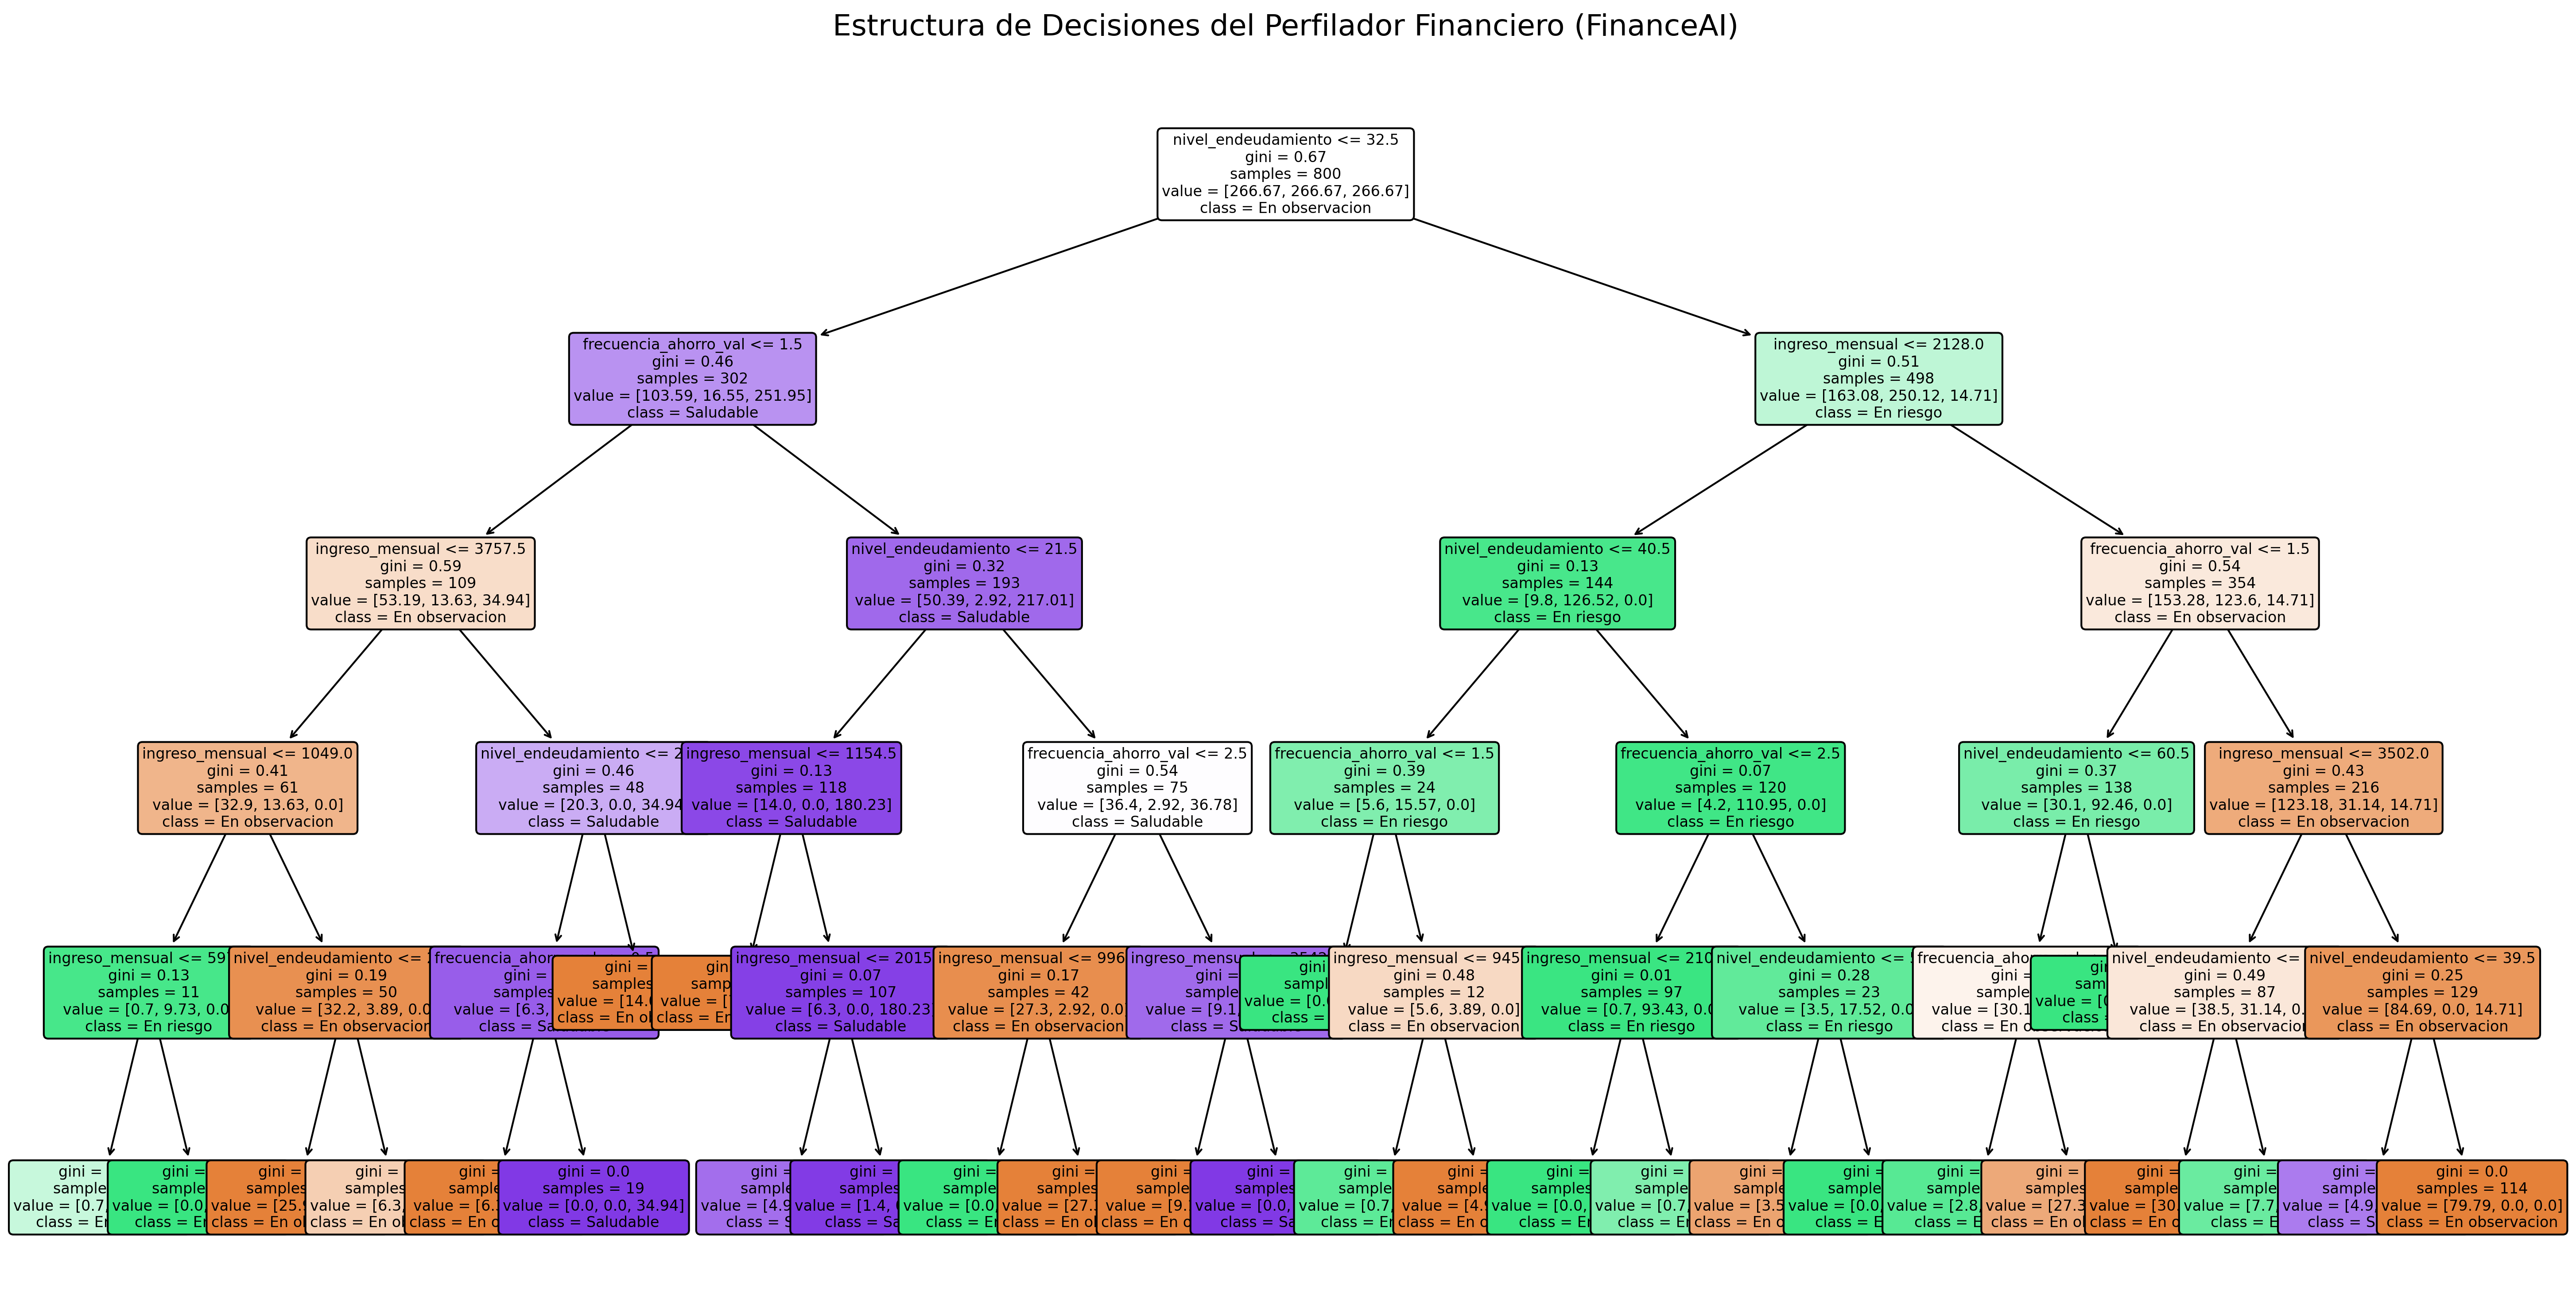

In [6]:
# SE PUEDE GRAFICAR EL ÁRBOL

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configurar figura gigante y alta definición (DPI=300) para evitar que los nodos se pisen
fig = plt.figure(figsize=(24, 12), dpi=300)

# Graficar el árbol con nodos redondeados, reduciendo la letra a 8 para que quepa en los cuadros
plot_tree(
    profiler_model, 
    feature_names=['ingreso_mensual', 'nivel_endeudamiento', 'frecuencia_ahorro_val'], 
    class_names=profiler_model.classes_, 
    filled=True, 
    rounded=True, 
    fontsize=8,
    precision=2 # Mostrar límites con máximo dos decimales para mayor nitidez
)

plt.title("Estructura de Decisiones del Perfilador Financiero (FinanceAI)", fontsize=16, pad=20)

# Guardar el gráfico en el disco con márgenes perfectos (bbox_inches='tight')
#path_imagen = 'models/arbol_decision.png'
#plt.savefig(path_imagen, bbox_inches='tight', dpi=300)

# También lo guardamos en la carpeta compartida con el Backend
#plt.savefig('../shared-models/arbol_decision.png', bbox_inches='tight', dpi=300)

#print(f"¡Imagen del árbol guardada exitosamente en {path_imagen} y en shared-models/!")
plt.show()

In [7]:
### Conclusiones
#### Nivel 0: El 56% tiene bajo endeudamiento. El endeudamiento es el factor más discriminante para clasificar riesgo financiero.
#### Nivel 1: 

In [9]:
# Notas generales de este notebook 

# Desde el punto 4 en adelante hay mucho territorio nuevo y desconocido

# Al separar los conjuntos de entrenamiento y prueba, usamos stratify.
# Mantiene idénticas las proporciones de las clases en ambos conjuntos de datos. Si el dataset original tiene 10% de transacciones de "Educación", tanto el set de entrenamiento como el de prueba conservarán exactamente un 10% de esa categoría, evitando sesgos de entrenamiento.

# Empaquetado mediante Pipeline
# Conectamos el procesador de texto (TfidfVectorizer) directamente con el clasificador (LogisticRegression) en un solo objeto Pipeline.
# Evita la fuga de datos (Data Leakage), garantizando que el vectorizador solo aprenda vocabulario del conjunto de entrenamiento y no del de testeo.
# Facilita la exportación a producción en un único archivo binario .onnx sin tener que exportar el preprocesamiento de texto por separado.

# Mapeo Manual de Variables Ordinales a Float (Ahorro)
# Convertimos la frecuencia de ahorro (Ninguna, Baja, Media, Alta en texto) a valores decimales (0.0, 1.0, 2.0, 3.0) en Python antes de pasarlo al modelo.
# Simplifica el contrato de comunicación con el backend. En lugar de procesar cadenas de texto o hacer conversiones complejas en Java, el archivo ONNX recibe un tensor numérico simple y directo de 3 variables floats (float_input de dimensión [None, 3]).

# Optimización del Árbol de Decisión (class_weight="balanced" y max_depth=5)
# Agregamos balanceo de peso en las clases y limitamos la profundidad máxima del árbol a 5.
# class_weight="balanced": Como descubrimos en el EDA que los usuarios saludables eran una minoría, este ajuste penaliza fuertemente al modelo cuando comete errores en clasificar usuarios en riesgo. Esto eleva drásticamente el Recall (sensibilidad al riesgo) del modelo, haciéndolo seguro para producción financiera (prevención de impagos).
# max_depth=5: Evita el sobreajuste (overfitting), impidiendo que el árbol memorice los datos sintéticos de forma excesivamente compleja y asegurando que las reglas lógicas finales sean sencillas e interpretables para negocio.

# Exportación a ONNX y Contrato JSON (metadata.json) (Lógica Java) 
# Definimos StringTensorType([None, 1]) para el NLP y FloatTensorType([None, 3]) para el perfilador. Además, escribimos el archivo metadata.json mapeando las salidas.
# El primer parámetro None representa el tamaño de lote (batch size) dinámico, permitiendo al Backend en Java procesar una sola transacción o miles en lote simultáneamente.
# metadata.json le indica a Java exactamente los nombres de entrada y las clases en texto que corresponden a las salidas del modelo, eliminando la necesidad de hardcodear datos y permitiendo actualizar los modelos en caliente sin recompilar la API.



